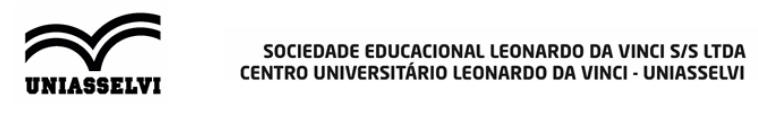

**Nome do Acadêmico e Matrícula:** <br>
**Carolina Oliveira Fagundes** (3085524) ;<br>
**Guilherme Arruda Santos** (3450160) ;<br>
**Gustavo Santiago Cazagranda** (3646488); <br>
**Rafaela Maria de Sá Rodrigues** (3258059).


# Projeto II - Futuro dos Dados e Aplicação de Big Data - Etapa I

TEMA: Análise das consultas realizadas pelo SUS


Base de Dados:
*   Kaggle:https://www.kaggle.com/datasets/joniarroba/noshowappointments


## Definição do TEMA:
O Sistema Único de Saúde – SUS consiste no conjunto de todas as ações e serviços de saúde prestados de forma gratuita pelo Estado (órgãos e instituições públicas) no âmbito federal, estadual e municipal. Partindo dessa premissa, para muitos cidadãos é a única forma de acesso à assistência médica e hospitalar no Brasil. Nesse sentido e diante da magnitude territorial, bem como pela grande população brasileira é salutar que se tenha dificuldade no gerenciamento de toda a estrutura e que ocorram filas para consulta eletivas, não só pela ausência de profissionais como também por questões tecnológicas.


>## Objetivo


Mapear características dos pacientes que faltam as consultas; e

Aplicar algoritmo de machine learning Keras com TensorFlow  visando a identificação de padrões na predição de consultas;

>## Especificação Técnica


**Dataset**: Para desenvolvimento desse projeto, será utilizado dataset específico formado pela base de dados de consultas do Sistema Único de Saúde. Os dados estão disponíveis em https://www.kaggle.com/datasets/joniarroba/noshowappointments <br>

Formato: A base de dados está em formato *.CSV, dividido em 10 colunas (features) conforme segue: ID do Paciente, Gênero, Idade, Data da Marcação, Data da Consulta, Bairro do Posto de Saúde, Escolaridade, Mensagem de Texto e No-Show. <br>

Variável independente ou preditora: Gênero ( O Gênero foi foi escolhida como variável independente por ser um dos fatores que podem impactar na diminuição do não comparecimento nas consultas) <br>

Variável dependente: Mensagem de Texto (Variável que pretende-se prever o No-Show ao longo dos envios) <br>

**DESCRIÇÃO DAS FEATURES** (Características):<br>
ID do Paciente: Identificação do Paciência;<br>
Gênero: Masculino ou Feminino;<br>
Idade: Idade do paciente;<br>
Data de Marcação: Data em que a consulta foi agendada;<br>
Bairro do Posto de Saúde: bairro onde o ocorrerá a consulta;<br>
Escolaridade: Se o paciente possui escolaridade. (True or False);<br>
Mensagem de Texto: Se o paciente recebeu SMS com as informações da consulta (True or False);<br>
No-Show: não comparecimento do paciente (Sim – Compareceu, Não – Não compareceu);<br>
Métodos de Pré-processamento: Limpeza e encode da base, onde serão removidos espaços em branco, e transposição de atributos em categóricos ordinais e encode dos dados.<br>
**Modos de aprendizado**: Supervisionado.<br>
**Algoritmo Avaliado**:  Rede Neural Artificial.<br>



## **Pré Processamento**

Importação das Bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix

Obtenção dos dados do *.CSV no Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = df=pd.read_csv("/content/drive/MyDrive/base_sus.csv")
df.tail()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
110522,2.572134e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596266e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557663e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213493e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No
110526,3.775115e+14,5629448,F,2016-04-27T13:30:56Z,2016-06-07T00:00:00Z,54,MARIA ORTIZ,0,0,0,0,0,1,No


Para rodar as gráficos em SeaBorn esse deve retirado do comentário e executado.

Detalhamento do DataSet

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [ ]:
# Convertendo ScheduledDay & AppointmentDay em data
df["ScheduledDay"]=pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"]=pd.to_datetime(df["AppointmentDay"])

In [ ]:
# Criando uma nova coluna "Wainting Time para apresentar o tempo de espera do paciente"
df['waiting_time']=(df['AppointmentDay']-df['ScheduledDay']).dt.days+1

In [ ]:
df.rename(columns = {'PatientId':'ID_Paciente', 'AppointmentID':'ID_Consulta', 'Gender':'Genero',
                     'ScheduledDay':'Dt_Agendamento', 'AppointmentDay':'Dt_Agendada', 'Age':'Idade',
                     'Neighbourhood':'Bairro', 'Scholarship':'Escolaridade', 'Hipertension':'Hipertensao',
                     'Diabetes':'Diabetes', 'Alcoholism':'Alcoolismo', 'Handcap':'Deficiente',
                     'SMS_received':'SMS_Recebido', 'No-show':'Compareceu', 'waiting_time':'Tempo_Espera'
                     }, inplace = True)

In [ ]:
# Visualização após as alterações e adições
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   ID_Paciente     110527 non-null  float64            
 1   ID_Consulta     110527 non-null  int64              
 2   Genero          110527 non-null  object             
 3   Dt_Agendamento  110527 non-null  datetime64[ns, UTC]
 4   Dt_Agendada     110527 non-null  datetime64[ns, UTC]
 5   Idade           110527 non-null  int64              
 6   Bairro          110527 non-null  object             
 7   Escolaridade    110527 non-null  int64              
 8   Hipertensao     110527 non-null  int64              
 9   Diabetes        110527 non-null  int64              
 10  Alcoolismo      110527 non-null  int64              
 11  Deficiente      110527 non-null  int64              
 12  SMS_Recebido    110527 non-null  int64              
 13  Compareceu    

[Text(0.5, 0, 'Gênero'), Text(0, 0.5, 'Não Comparecimento')]

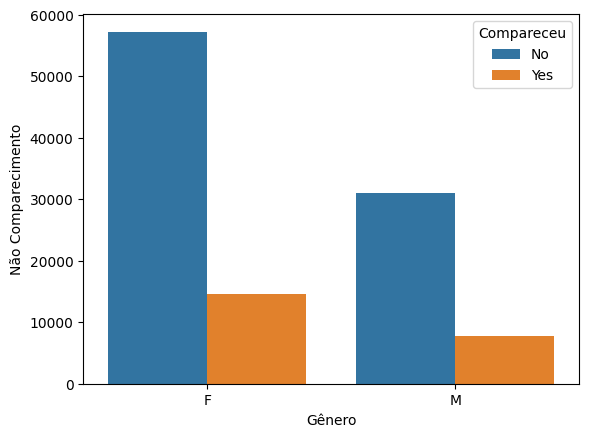

In [ ]:
# Seaborn - Quantos homens e mulheres aparecem nas consultas?
graph = sns.countplot(data=df,x="Genero",hue="Compareceu")
graph.set(xlabel='Gênero', ylabel='Não Comparecimento')

In [ ]:
# Do total de consultas, qual porcentagem de homem/mulher compareceu?
att_f=df[(df["Compareceu"]=="Yes") & (df["Genero"]=="F")]["Compareceu"].count()
noatt_f=df[(df["Compareceu"]=="No") & (df["Genero"]=="F")]["Compareceu"].count()
att_m=df[(df["Compareceu"]=="Yes") & (df["Genero"]=="M")]["Compareceu"].count()
noatt_m=df[(df["Compareceu"]=="No") & (df["Genero"]=="M")]["Compareceu"].count()
print("A porcentagem de mulheres atendidas em relação ao total é de {}%".format(round(att_f/(att_f+noatt_f)*100,2)))
print("A porcentagem de homens antedidos em relação ao total é de {}%".format(round(att_m/(att_m+noatt_m)*100,2)))

A porcentagem de mulheres atendidas em relação ao total é de 20.31%
A porcentagem de homens antedidos em relação ao total é de 19.97%


**O tempo de espera afeta o comparecimento na consulta?**

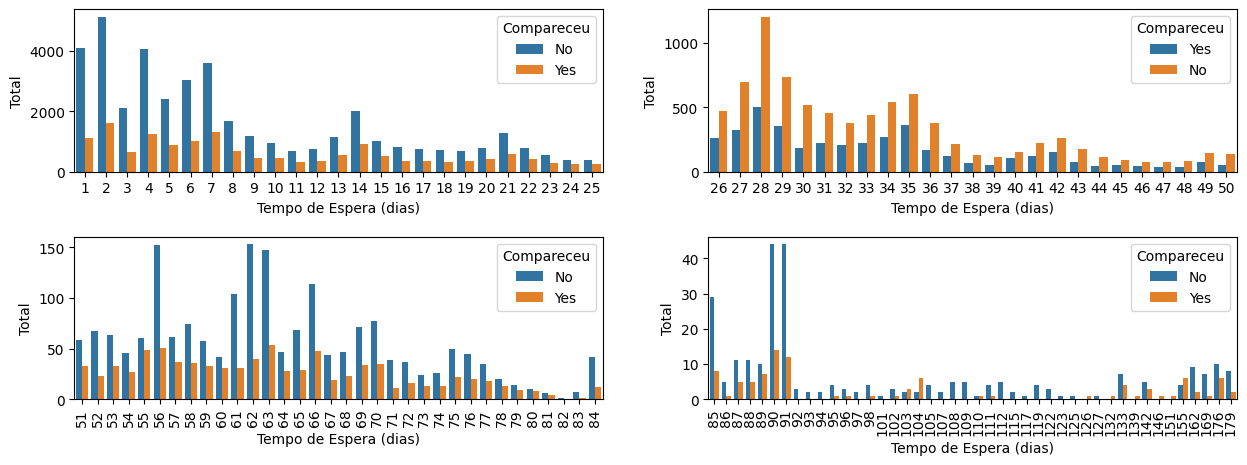

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15,5))

graph1 = sns.countplot(data=df[(df["Tempo_Espera"] > 0) & (df["Tempo_Espera"] <= 25)],
              x="Tempo_Espera", hue="Compareceu", ax=axs[0,0])

graph2 = sns.countplot(data=df[(df["Tempo_Espera"] > 25) & (df["Tempo_Espera"] <= 50)],
              x="Tempo_Espera", hue="Compareceu", ax=axs[0,1])

graph3 = sns.countplot(data=df[(df["Tempo_Espera"] > 50) & (df["Tempo_Espera"] < 85)],
              x="Tempo_Espera", hue="Compareceu" ,ax=axs[1,0])

graph4 = sns.countplot(data=df[df["Tempo_Espera"] >= 85],
              x="Tempo_Espera", hue="Compareceu", ax=axs[1,1], orient="h")

axs[1,0].tick_params(axis='x', labelrotation=90)
axs[1,1].tick_params(axis='x', labelrotation=90)

fig.subplots_adjust(bottom=0.1, hspace=0.4)

graph1.set(xlabel='Tempo de Espera (dias)', ylabel='Total')
graph2.set(xlabel='Tempo de Espera (dias)', ylabel='Total')
graph3.set(xlabel='Tempo de Espera (dias)', ylabel='Total')
graph4.set(xlabel='Tempo de Espera (dias)', ylabel='Total')

plt.show()

#**Há 4 gráficos e neles é possível observar que o maior volume de pessoas que não comparecem ocorre entre 26 dias e 50 dias de espera.**

**A idade afeta a frequência de comparecimento nas consultas?**

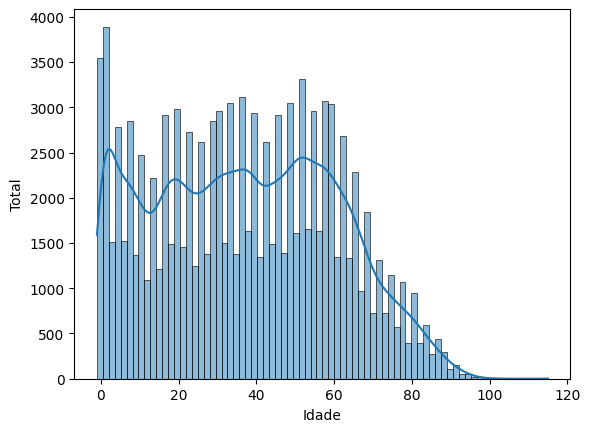

In [ ]:
#frequência de idade de pessoas que agendam consultas
hist = sns.histplot(df["Idade"],kde=True)
hist.set(xlabel='Idade', ylabel='Total')
plt.show();

In [ ]:
df["Idade_Media"]=df["Idade"].apply(lambda x: "age 1-20" if (x>0)&(x<=20)
                                  else ("age 21-40" if (x>20)&(x<=40)
                                  else ("age 41-60" if (x>40)&(x<=60)
                                  else "age >60")))

<Axes: xlabel='Idade_Media', ylabel='count'>

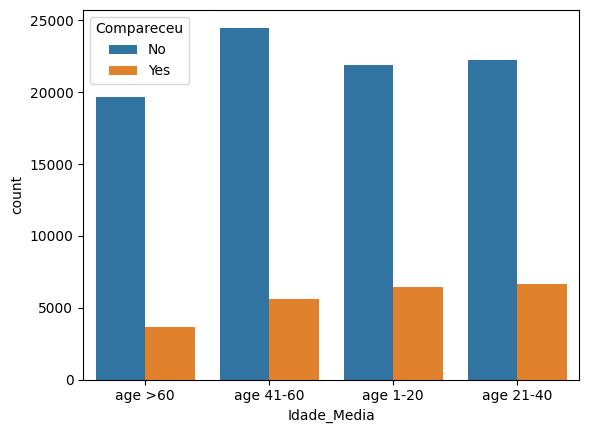

In [ ]:
sns.countplot(data=df,x="Idade_Media",hue="Compareceu")

In [ ]:
def normalized(feature):
    counts=df.groupby([feature,"Compareceu"])["Compareceu"].size()
    sums = counts.groupby(level=0).transform('sum')
    normalized_counts = counts / sums
    return normalized_counts
normalized("Idade_Media")

Idade_Media  Compareceu
age 1-20     No            0.771910
             Yes           0.228090
age 21-40    No            0.770210
             Yes           0.229790
age 41-60    No            0.814135
             Yes           0.185865
age >60      No            0.843576
             Yes           0.156424
Name: Compareceu, dtype: float64

**O bairro terá relação com o comparecimento ou não na consulta?**

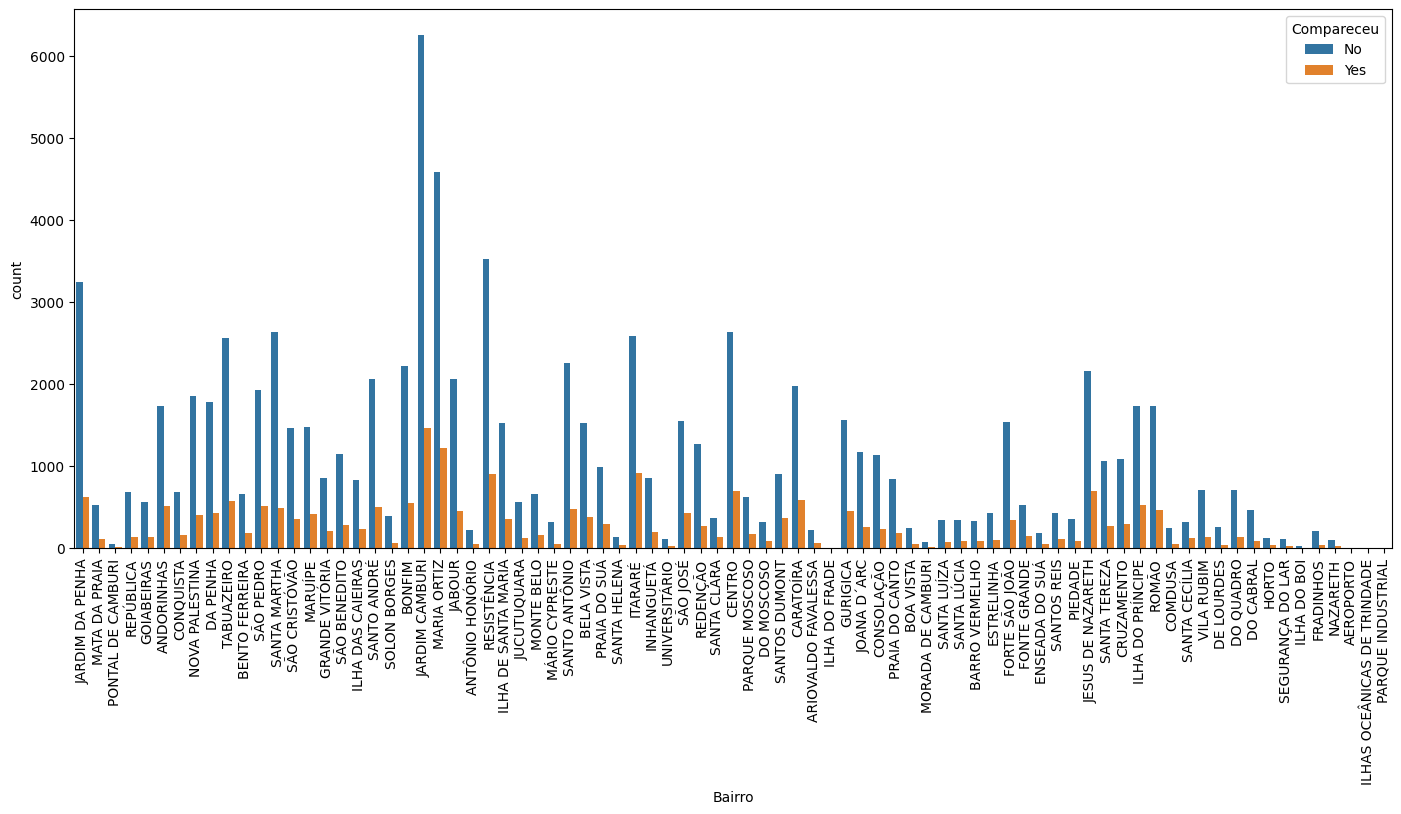

In [ ]:
plt.figure(figsize=(17,7))
sns.countplot(data=df,x="Bairro",hue="Compareceu")
plt.tick_params(axis='x', labelrotation=90)

In [ ]:
# Porcentual de comparecimento por Bairro
normalized_fuc=normalized("Bairro")
# Filtrando para apenas pessoas que compareceram
normalized_fuc.loc[normalized_fuc.index.get_level_values("Compareceu") == "Yes"].sort_values(ascending=False)

Bairro                       Compareceu
ILHAS OCEÂNICAS DE TRINDADE  Yes           1.000000
SANTOS DUMONT                Yes           0.289185
SANTA CECÍLIA                Yes           0.274554
SANTA CLARA                  Yes           0.264822
ITARARÉ                      Yes           0.262664
                                             ...   
DE LOURDES                   Yes           0.154098
SOLON BORGES                 Yes           0.147122
MÁRIO CYPRESTE               Yes           0.145553
AEROPORTO                    Yes           0.125000
ILHA DO BOI                  Yes           0.085714
Name: Compareceu, Length: 80, dtype: float64

In [ ]:
df["Bairro"].value_counts().iloc[-5:]

ILHA DO BOI                    35
ILHA DO FRADE                  10
AEROPORTO                       8
ILHAS OCEÂNICAS DE TRINDADE     2
PARQUE INDUSTRIAL               1
Name: Bairro, dtype: int64

Podemos notar que o maior porcentual de comparecimento é in Santos Dumont (29%). Deve-se considerar também que Ilhas Oceânicas de Trindade tem apenas duas consultas e ambas compareceram.

**As doenças e Escolaridade dos pacientes afetam no comparecimento?**

<Axes: xlabel='Escolaridade', ylabel='count'>

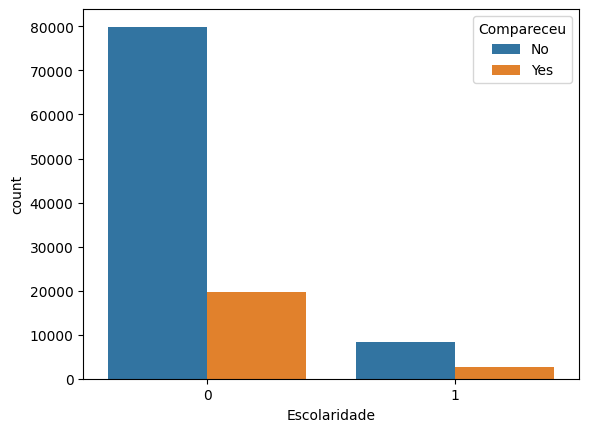

In [ ]:
sns.countplot(data=df,x="Escolaridade",hue="Compareceu")

In [ ]:
normalized("Escolaridade")

Escolaridade  Compareceu
0             No            0.801928
              Yes           0.198072
1             No            0.762637
              Yes           0.237363
Name: Compareceu, dtype: float64

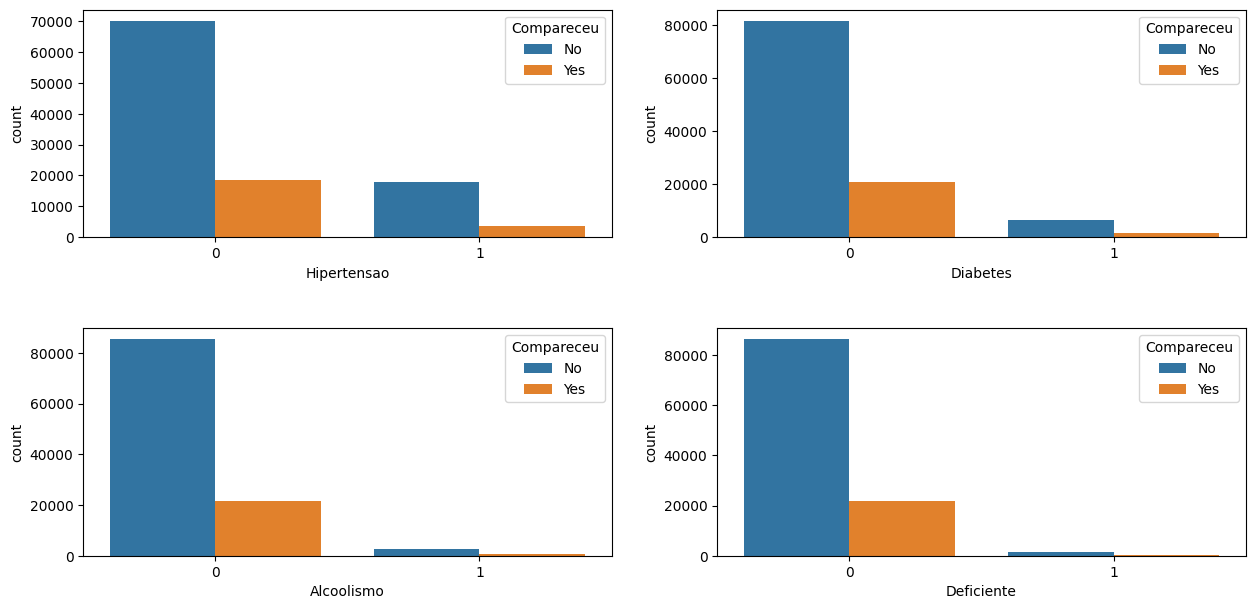

In [ ]:
def diseases(x1,x2,x3,x4):
    fig,axs = plt.subplots(nrows=2,ncols=2, figsize=(15,7))
    sns.countplot(data=df,x=x1,hue="Compareceu",ax=axs[0,0])
    sns.countplot(data=df,x=x2,hue="Compareceu",ax=axs[0,1])
    sns.countplot(data=df,x=x3,hue="Compareceu",ax=axs[1,0])
    sns.countplot(data=df[df[x4]<2],x=x4,hue="Compareceu",ax=axs[1,1])
    fig.subplots_adjust(bottom=0.1, hspace=0.4)

diseases("Hipertensao","Diabetes","Alcoolismo","Deficiente")

In [ ]:
df["Deficiente"]=df["Deficiente"].apply(lambda x: 1 if x != 0 else 0)

def diseases_perc(diseases):
    x=normalized(diseases)
    result=x.loc[x.index.get_level_values("Compareceu") == "Yes"]
    return result
print(diseases_perc("Hipertensao"))
print("*"*50)
print(diseases_perc("Diabetes"))
print("*"*50)
print(diseases_perc("Alcoolismo"))
print("*"*50)
print(diseases_perc("Deficiente"))

Hipertensao  Compareceu
0            Yes           0.209037
1            Yes           0.173020
Name: Compareceu, dtype: float64
**************************************************
Diabetes  Compareceu
0         Yes           0.203628
1         Yes           0.180033
Name: Compareceu, dtype: float64
**************************************************
Alcoolismo  Compareceu
0           Yes           0.201946
1           Yes           0.201488
Name: Compareceu, dtype: float64
**************************************************
Deficiente  Compareceu
0           Yes           0.202353
1           Yes           0.181615
Name: Compareceu, dtype: float64


**O envio de SMS tem relevância?**

<Axes: xlabel='SMS_Recebido', ylabel='count'>

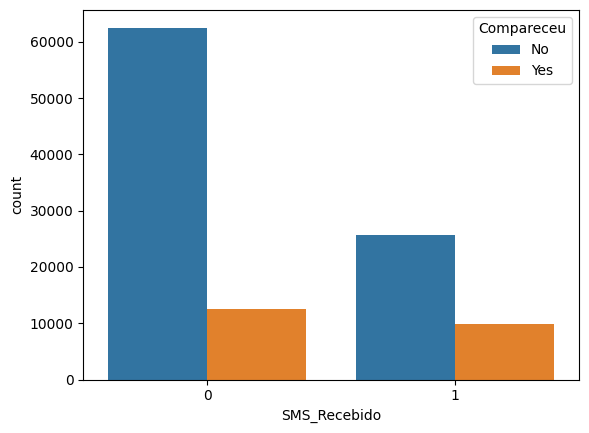

In [ ]:
sns.countplot(data=df,x="SMS_Recebido",hue="Compareceu")

In [ ]:
normalized("SMS_Recebido").loc[normalized("SMS_Recebido").index.get_level_values("Compareceu") == "Yes"]

SMS_Recebido  Compareceu
0             Yes           0.167033
1             Yes           0.275745
Name: Compareceu, dtype: float64

In [ ]:
df["SMS_Recebido"].value_counts()

0    75045
1    35482
Name: SMS_Recebido, dtype: int64

Conclusão da análise

Muitos fatores vão ser refletidos no comparecimento ou não, mas baseado nesse database, o maior impacto é no envio de SMS. Foram enviados apenas 35k SMS (32%) para os pacientes e cerca de 27,5% compareceu a consulta.

A principal limitação dos dados seria a ausência da distância de moradia para o consultório, acredito que isso teria um impacto significante na nossa análise.

In [ ]:
data.describe()

,ID_Paciente,ID_Consulta,Genero,Idade,Escolaridade,Hipertensao,Diabetes,Alcoolismo,Deficiente,SMS_Recebido,...,N_SANTOS REIS,N_SEGURANÇA DO LAR,N_SOLON BORGES,N_SÃO BENEDITO,N_SÃO CRISTÓVÃO,N_SÃO JOSÉ,N_SÃO PEDRO,N_TABUAZEIRO,N_UNIVERSITÁRIO,N_VILA RUBIM
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,...,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,0.350023,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,...,0.004949,0.001312,0.004243,0.013019,0.016611,0.017887,0.022148,0.028337,0.001375,0.007699
std,2.560949e+14,7.129575e+04,0.476979,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873,...,0.070175,0.036197,0.065003,0.113358,0.127811,0.132541,0.147167,0.165934,0.037059,0.087409
min,3.921784e+04,5.030230e+06,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,0.000000,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,1.000000,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,9.999816e+14,5.790484e+06,1.000000,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
tf.random.set_seed(100)

In [ ]:
print("Total de valores vazios:", data.isna().sum().sum())

Total de valores vazios: 0


In [ ]:
data = data.drop(['ID_Paciente', 'ID_Consulta'], axis=1)

In [ ]:
data

'Dt_Agendamento'

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   ID_Paciente     110527 non-null  float64            
 1   ID_Consulta     110527 non-null  int64              
 2   Genero          110527 non-null  object             
 3   Dt_Agendamento  110527 non-null  datetime64[ns, UTC]
 4   Dt_Agendada     110527 non-null  datetime64[ns, UTC]
 5   Idade           110527 non-null  int64              
 6   Bairro          110527 non-null  object             
 7   Escolaridade    110527 non-null  int64              
 8   Hipertensao     110527 non-null  int64              
 9   Diabetes        110527 non-null  int64              
 10  Alcoolismo      110527 non-null  int64              
 11  Deficiente      110527 non-null  int64              
 12  SMS_Recebido    110527 non-null  int64              
 13  Compareceu    

In [ ]:
data.head(5)

,ID_Paciente,ID_Consulta,Genero,Dt_Agendamento,Dt_Agendada,Idade,Bairro,Escolaridade,Hipertensao,Diabetes,Alcoolismo,Deficiente,SMS_Recebido,Compareceu,Tempo_Espera
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0


In [ ]:
data = data.rename(columns={'Dt_Agendamento': "Dt_Agendamento", 'Dt_Agendada': "Dt_Agendada"})

data['Ano_Agendamento'] = data['Dt_Agendamento'].dt.year
data['Mes_Agendamento'] = data['Dt_Agendamento'].dt.month
data['Dia_Agendamento'] = data['Dt_Agendamento'].dt.day
data['Hora_Agendamento'] = data['Dt_Agendamento'].dt.hour
data['Minuto_Agendamento'] = data['Dt_Agendamento'].dt.minute
data['Segundos_Agendamento'] = data['Dt_Agendamento'].dt.second

data['Ano_Agendado'] = data['Dt_Agendada'].dt.year
data['Mes_Agendado'] = data['Dt_Agendada'].dt.month
data['Dia_Agendado'] = data['Dt_Agendada'].dt.day

data = data.drop(['Dt_Agendamento', 'Dt_Agendada'], axis=1)

In [ ]:
data


,ID_Paciente,ID_Consulta,Genero,Idade,Bairro,Escolaridade,Hipertensao,Diabetes,Alcoolismo,Deficiente,...,Tempo_Espera,Ano_Agendamento,Mes_Agendamento,Dia_Agendamento,Hora_Agendamento,Minuto_Agendamento,Segundos_Agendamento,Ano_Agendado,Mes_Agendado,Dia_Agendado
0,2.987250e+13,5642903,F,62,JARDIM DA PENHA,0,1,0,0,0,...,0,2016,4,29,18,38,8,2016,4,29
1,5.589978e+14,5642503,M,56,JARDIM DA PENHA,0,0,0,0,0,...,0,2016,4,29,16,8,27,2016,4,29
2,4.262962e+12,5642549,F,62,MATA DA PRAIA,0,0,0,0,0,...,0,2016,4,29,16,19,4,2016,4,29
3,8.679512e+11,5642828,F,8,PONTAL DE CAMBURI,0,0,0,0,0,...,0,2016,4,29,17,29,31,2016,4,29
4,8.841186e+12,5642494,F,56,JARDIM DA PENHA,0,1,1,0,0,...,0,2016,4,29,16,7,23,2016,4,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,56,MARIA ORTIZ,0,0,0,0,0,...,35,2016,5,3,9,15,35,2016,6,7
110523,3.596266e+12,5650093,F,51,MARIA ORTIZ,0,0,0,0,0,...,35,2016,5,3,7,27,33,2016,6,7
110524,1.557663e+13,5630692,F,21,MARIA ORTIZ,0,0,0,0,0,...,41,2016,4,27,16,3,52,2016,6,7
110525,9.213493e+13,5630323,F,38,MARIA ORTIZ,0,0,0,0,0,...,41,2016,4,27,15,9,23,2016,6,7


In [ ]:
{column: data[column].unique() for column in data.select_dtypes('object').columns}

{'Genero': array(['F', 'M'], dtype=object),
 'Bairro': array(['JARDIM DA PENHA', 'MATA DA PRAIA', 'PONTAL DE CAMBURI',
        'REPÚBLICA', 'GOIABEIRAS', 'ANDORINHAS', 'CONQUISTA',
        'NOVA PALESTINA', 'DA PENHA', 'TABUAZEIRO', 'BENTO FERREIRA',
        'SÃO PEDRO', 'SANTA MARTHA', 'SÃO CRISTÓVÃO', 'MARUÍPE',
        'GRANDE VITÓRIA', 'SÃO BENEDITO', 'ILHA DAS CAIEIRAS',
        'SANTO ANDRÉ', 'SOLON BORGES', 'BONFIM', 'JARDIM CAMBURI',
        'MARIA ORTIZ', 'JABOUR', 'ANTÔNIO HONÓRIO', 'RESISTÊNCIA',
        'ILHA DE SANTA MARIA', 'JUCUTUQUARA', 'MONTE BELO',
        'MÁRIO CYPRESTE', 'SANTO ANTÔNIO', 'BELA VISTA', 'PRAIA DO SUÁ',
        'SANTA HELENA', 'ITARARÉ', 'INHANGUETÁ', 'UNIVERSITÁRIO',
        'SÃO JOSÉ', 'REDENÇÃO', 'SANTA CLARA', 'CENTRO', 'PARQUE MOSCOSO',
        'DO MOSCOSO', 'SANTOS DUMONT', 'CARATOÍRA', 'ARIOVALDO FAVALESSA',
        'ILHA DO FRADE', 'GURIGICA', 'JOANA D´ARC', 'CONSOLAÇÃO',
        'PRAIA DO CANTO', 'BOA VISTA', 'MORADA DE CAMBURI', 'SANTA LUÍZA

In [ ]:
def binary_encode(df, column, positive_value):
    df = df.copy()
    df[column] = df[column].apply(lambda x: 1 if x == positive_value else 0)
    return df

def onehot_encode(df, column, prefix):
    df = df.copy()
    dummies = pd.get_dummies(df[column], prefix=prefix)
    df = pd.concat([df, dummies], axis=1)
    df = df.drop(column, axis=1)
    return df

In [ ]:
data = binary_encode(data, 'Genero', positive_value='M')
data = binary_encode(data, 'Compareceu', positive_value='Yes')

data = onehot_encode(data, 'Bairro', prefix='N')

In [ ]:
data

,ID_Paciente,ID_Consulta,Genero,Idade,Escolaridade,Hipertensao,Diabetes,Alcoolismo,Deficiente,SMS_Recebido,...,N_SANTOS REIS,N_SEGURANÇA DO LAR,N_SOLON BORGES,N_SÃO BENEDITO,N_SÃO CRISTÓVÃO,N_SÃO JOSÉ,N_SÃO PEDRO,N_TABUAZEIRO,N_UNIVERSITÁRIO,N_VILA RUBIM
0,2.987250e+13,5642903,0,62,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5.589978e+14,5642503,1,56,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4.262962e+12,5642549,0,62,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,8.679512e+11,5642828,0,8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8.841186e+12,5642494,0,56,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,0,56,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
110523,3.596266e+12,5650093,0,51,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
110524,1.557663e+13,5630692,0,21,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
110525,9.213493e+13,5630323,0,38,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
y = data['Compareceu'].copy()
X = data.drop('Compareceu', axis=1).copy()

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=100)

In [ ]:
print("Class Distribution (Positive to Negative): {:.1f}% / {:.1f}%".format(y_train.mean() * 100, (1 - y_train.mean()) * 100))

Class Distribution (Positive to Negative): 20.1% / 79.9%


In [ ]:
inputs = tf.keras.Input(shape=(X.shape[1]))
x = tf.keras.layers.Dense(64, activation='relu')(inputs)
x = tf.keras.layers.Dense(64, activation='relu')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/100
1935/1935 [==============================] - 7s 3ms/step - loss: 0.4847 - accuracy: 0.7977 - auc: 0.6411 - val_loss: 0.4777 - val_accuracy: 0.7971 - val_auc: 0.6660
Epoch 2/100
1935/1935 [==============================] - 3s 2ms/step - loss: 0.4682 - accuracy: 0.7988 - auc: 0.6841 - val_loss: 0.4725 - val_accuracy: 0.7973 - val_auc: 0.6781
Epoch 3/100
1935/1935 [==============================] - 3s 2ms/step - loss: 0.4605 - accuracy: 0.7995 - auc: 0.7022 - val_loss: 0.4690 - val_accuracy: 0.7977 - val_auc: 0.6917
Epoch 4/100
1935/1935 [==============================] - 4s 2ms/step - loss: 0.4555 - accuracy: 0.7991 - auc: 0.7130 - val_loss: 0.4677 - val_accuracy: 0.7980 - val_auc: 0.6941
Epoch 5/100
1935/1935 [==============================] - 4s 2ms/step - loss: 0.4517 - accuracy: 0.8004 - auc: 0.7209 - val_loss: 0.4651 - val_accuracy: 0.7981 - val_auc: 0.7000
Epoch 6/100
1935/1935 [==============================] - 3s 2ms/step - loss: 0.4480 - accuracy: 0.8006 - auc: 0.728

In [ ]:
model.evaluate(X_test, y_test)

1037/1037 [==============================] - 3s 3ms/step - loss: 0.4601 - accuracy: 0.7968 - auc: 0.7112


[0.4601331651210785, 0.7968274354934692, 0.7111960649490356]

In [ ]:
y_true = np.array(y_test)
y_pred = np.squeeze(np.array(model.predict(X_test) >= 0.5, dtype=np.int))

1037/1037 [==============================] - 3s 3ms/step


<ipython-input-96-c0623fde7feb>:2: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  y_pred = np.squeeze(np.array(model.predict(X_test) >= 0.5, dtype=np.int))


In [ ]:
print("Classification Report:\n\n", classification_report(y_true, y_pred))

Classification Report:

               precision    recall  f1-score   support

           0       0.80      0.99      0.89     26427
           1       0.50      0.05      0.09      6732

    accuracy                           0.80     33159
   macro avg       0.65      0.52      0.49     33159
weighted avg       0.74      0.80      0.72     33159



In [ ]:
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

Confusion Matrix:
 [[26085   342]
 [ 6395   337]]
